In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath('../../'))
from src.analysis.ingredients_analysis import plot_ingrs_daily_consumption
from src.analysis.metrics import calculate_rmse, calculate_mape
from src.modeling.feature_engineering import *
from src.modeling.model import *
from src.modeling.evaluation import *

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn

In [2]:
# Restaurant data with the 25 most frequent ingredients
daily_consumption_df = pd.read_csv('../../data/restaurant_daily_consumption.csv', index_col=0, parse_dates=True)
display(daily_consumption_df)

numerical_features = daily_consumption_df.columns
print(numerical_features)

,Salt,Sugar,Clove,Paprika
Date,,,,
2019-01-01,153.557043,1573.765650,0.097426,2.455129
2019-01-02,101.122931,1036.382257,0.064158,1.616792
2019-01-03,119.849399,1228.304898,0.076040,1.916198
2019-01-04,97.377637,997.997729,0.061782,1.556911
2019-01-05,202.245861,2072.764515,0.128317,3.233584
...,...,...,...,...
2019-06-26,116.104106,1189.920370,0.073663,1.856317
2019-06-27,205.991155,2111.149043,0.130693,3.293465
2019-06-28,179.774099,1842.457347,0.114059,2.874297


Index(['Salt', 'Sugar', 'Clove', 'Paprika'], dtype='object')


##### Scale Numerical Features

In [3]:
# Applying feature scaling to numerical features
scaler, scaled_numerical_df = apply_scale_to_numerical_features(daily_consumption_df, numerical_features)

daily_consumption_scaled_df = scaled_numerical_df
display(daily_consumption_scaled_df)

,Salt,Sugar,Clove,Paprika
Date,,,,
2019-01-01,-0.401511,-0.401511,-0.401511,-0.401511
2019-01-02,-0.829631,-0.829631,-0.829631,-0.829631
2019-01-03,-0.676731,-0.676731,-0.676731,-0.676731
2019-01-04,-0.860211,-0.860211,-0.860211,-0.860211
2019-01-05,-0.003970,-0.003970,-0.003970,-0.003970
...,...,...,...,...
2019-06-26,-0.707311,-0.707311,-0.707311,-0.707311
2019-06-27,0.026610,0.026610,0.026610,0.026610
2019-06-28,-0.187451,-0.187451,-0.187451,-0.187451


##### Create Lag Features

In [4]:
window = 9
feature_columns = numerical_features
target_columns = numerical_features
(time_sequences_df, X, y) = generate_lag_features(daily_consumption_scaled_df, feature_columns, target_columns , window)
#print("Time-Shifted Features: ")
#display(time_sequences_df)
#print(f"X numpy: {X.shape}, Dimensions: {X.ndim}")
#print(f"y numpy: {y.shape}, Dimensions: {y.ndim}", '\n')

##### Apply Holdout Cross-Validation

In [5]:
# Determine the split index for training and testing data - Holdout cross-validation
split_index = int(len(X) * 0.82) 
print("split_index: ", split_index)

# Split the data into training and testing sets
X_train, X_test = X[:split_index], X[split_index:] 
y_train, y_test = y[:split_index], y[split_index:]

#print(f"X_test numpy: {X_test.shape}, Dimensions: {X_test.ndim}")

# Convert the numpy arrays to PyTorch tensors
X_train, X_test = torch.tensor(X_train).float(), torch.tensor(X_test).float()
y_train, y_test = torch.tensor(y_train).float(), torch.tensor(y_test).float()

#print(f"X_test tensor: {X_test.shape}, Dimensions: {X_test.ndim}")

split_index:  141


In [6]:
from torch.utils.data import  DataLoader
    
train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Iterate over the train_dataloader
# for _, batch in enumerate(train_dataloader):
#     x_batch, y_batch = batch[0], batch[1]
#     print(x_batch.shape, y_batch.shape)
#     print(batch)
#     break

In [7]:
features_number = len(feature_columns)
print("features_number: ", features_number)
hidden_size = 50
num_stack_layers = 2
output_size = len(target_columns)
print("output_size: ", output_size)

print("Creating LSTM model ...")
model = LSTM(features_number, hidden_size, num_stack_layers, output_size)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(model)

features_number:  4
output_size:  4
Creating LSTM model ...
LSTM(
  (lstm): LSTM(4, 50, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=50, out_features=4, bias=True)
)


In [8]:
import torch.optim as optim

# Hyperparameters
learning_rate = 0.001
num_epochs = 100
patience = 20  # Number of epochs to wait for improvement before stopping

# Initialize model, loss function, and optimizer
loss_function = torch.nn.MSELoss()  # nn.MSELoss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate) 

# Early stopping variables
best_val_loss = float('inf') 
best_epoch = 0
epochs_no_improve = 0  # Counts epochs without improvement

best_train_pred, train_actuals = [], []
best_test_pred, test_actuals = [], []

train_loss_hist =[]
test_loss_hist =[]

# Training and evaluation
print("LSTM modeling and training ...")

for epoch in range(num_epochs):
    # Training phase
    train_loss, train_predictions, train_actuals = train_loop(train_dataloader, model, loss_function, optimizer, device)
    train_loss_hist.append(train_loss)

    # Validation phase
    val_loss, test_predictions, test_actuals = test_loop(test_dataloader, model, loss_function, device)
    test_loss_hist.append(val_loss)

    #print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss}, Val Loss: {val_loss}')

    # Update the best_val_loss
    if val_loss < best_val_loss: 
        best_val_loss = val_loss
        best_epoch = epoch + 1
        epochs_no_improve = 0
        #print(f"Best validation loss updated to {best_val_loss} at epoch {best_epoch}\n")

        best_train_pred = train_predictions
        train_actuals = train_actuals
        best_test_pred = test_predictions
        test_actuals = test_actuals
    else:
        epochs_no_improve += 1
    # Early stopping: Stop if no improvement after 'patience' epochs
    if epochs_no_improve >= patience:
        print(f"Early stopping at epoch {epoch+1}, no improvement in {patience} consecutive epochs.")
        break

print(f"Training completed. Best epoch: {best_epoch}, Best Validation Loss: {best_val_loss}")

LSTM modeling and training ...
Early stopping at epoch 47, no improvement in 20 consecutive epochs.
Training completed. Best epoch: 27, Best Validation Loss: 0.3602108210325241


#### Plotting the Learning Curve

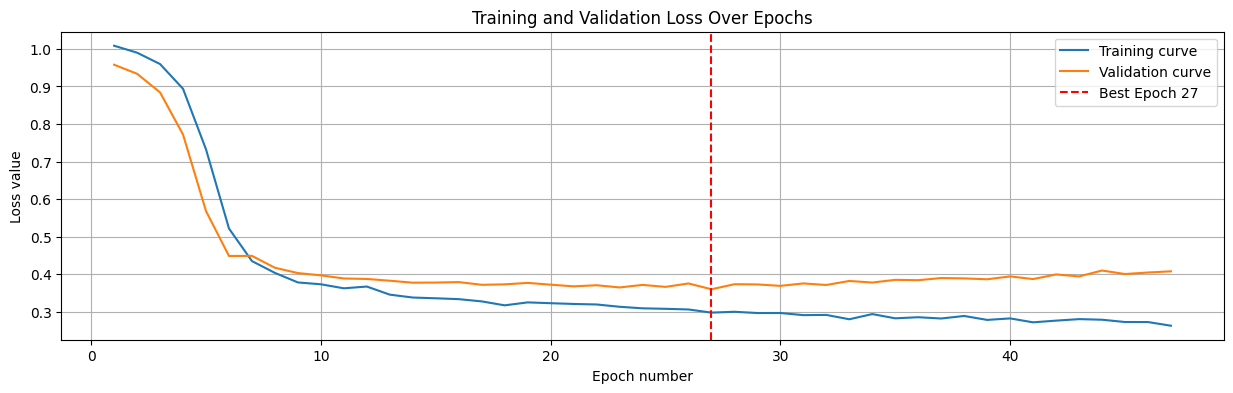

In [9]:
# Plot the training and validation loss
epochs_range = range(1, len(train_loss_hist) + 1)

plt.figure(figsize=(15, 4))
plt.plot(epochs_range, train_loss_hist, label='Training curve') # color='red'
plt.plot(epochs_range, test_loss_hist, label='Validation curve')    # , color='blue'
plt.axvline(best_epoch, linestyle='--', color='red', label=f'Best Epoch {best_epoch}')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch number')
plt.ylabel('Loss value')
plt.legend()
plt.grid(True)
plt.show()

#### Denormalize and plot the best results

Salt RMSE:  73.19639
Sugar RMSE:  756.4645
Clove RMSE:  0.04691478
Paprika RMSE:  1.1712496


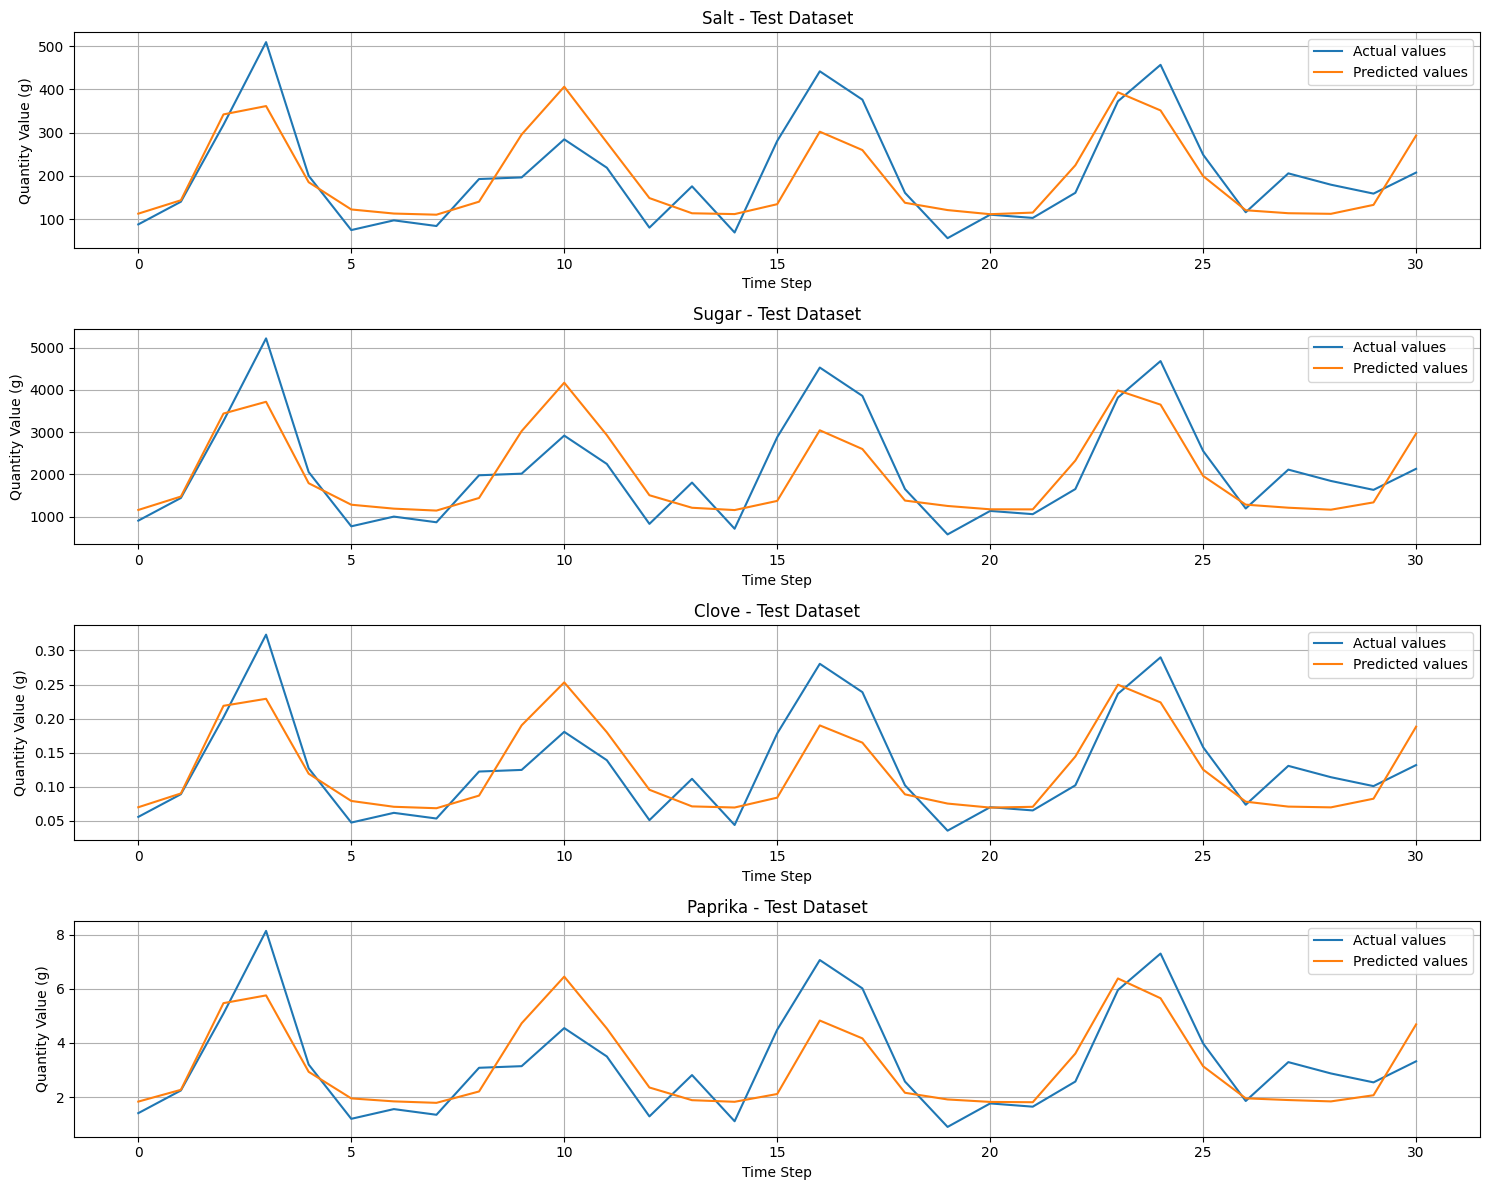

In [10]:
train_predictions, train_actuals = apply_denormalization(scaler, best_train_pred, train_actuals)
test_predictions, test_actuals = apply_denormalization(scaler, best_test_pred, test_actuals)

# Plotting all results in a single column figure
fig, axes = plt.subplots(output_size, 1, figsize=(15, 3 * output_size))

for idx, ingredient in enumerate(target_columns):
   
    #_, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))  #  Create a grid of subplots (1 row, 2 columns)
    # # Training data
    # ingr_train_pred = train_predictions[:, idx].reshape(-1, 1)
    # ingr_train_actuals = train_actuals[:, idx].reshape(-1, 1)
    # Testing data
    ingr_test_pred = test_predictions[:, idx].reshape(-1, 1)
    ingr_test_actuals = test_actuals[:, idx].reshape(-1, 1)

    ingr_rmse = calculate_rmse(ingr_test_actuals, ingr_test_pred)
    print(f'{ingredient} RMSE: ', ingr_rmse)
    # ingr_mape = calculate_mape(ingr_test_actuals, ingr_test_pred)
    # print(f'{ingredient} MAPE: ', ingr_mape, "\n")

    ax = axes[idx]
    ax.plot(ingr_test_actuals, label='Actual values')
    ax.plot(ingr_test_pred, label='Predicted values')
    ax.set_title(f'{ingredient} - Test Dataset')
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Quantity Value (g)')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

#### Short-Term Forecast (Next 7 Days of July 2019)

- Time Serie Dataset: 1 January - 30 June

- Time Serie Dataset with Lag: (1 January + window) - 30 June, eg. if W=4 => 5 January - 30 June

- Existing Forecast Dates = 30 days, represents the forecast consumption in existing dates (to compare)

- Future Forecast Dates = 7 days , represents the forecast consumption in future dates

- Total Forecast Dates = Existing Forecast Dates + Future Forecast Dates = 37 days

In [11]:
def generate_total_forecast_dates(orignal_dates_df, number_of_forecast_days, number_of_future_days):
    # Get the last date
    last_date = orignal_dates_df[-1]

    # Generate the next 9 future dates
    future_dates = pd.date_range(start=last_date + pd.DateOffset(1), periods=number_of_future_days)
    
    # Concatenate the original index with the future dates
    total_forecast_dates = orignal_dates_df.append(future_dates)

    # Convert to DatetimeIndex and normalize the dates
    total_forecast_dates = pd.DatetimeIndex(total_forecast_dates).normalize()

    # Select only the forecasted range
    total_forecast_dates = total_forecast_dates[-number_of_forecast_days:]

    return total_forecast_dates

In [12]:
# Parameters
num_current_steps = 30  # the number of existing time steps to forecast
num_future_steps = 7    # the number of future time steps to forecast
num_total_forecast_dates = num_current_steps + num_future_steps # the number of total time steps to forecast

total_forecast_dates = generate_total_forecast_dates(daily_consumption_df.index[window:], num_total_forecast_dates, num_future_steps)
print(total_forecast_dates)

date_to_find = '2019-06-01' # entry prediction
row_index = time_sequences_df.index.get_loc(date_to_find)
print("row_index: ", row_index)
entry_data = X[row_index]
 
# Initialize a list to store the forecasted values
forecasted_values = []

# Use the trained model to forecast future values (30 last days and 7 future days)
with torch.no_grad():
    for idx in range(num_total_forecast_dates):
        #print("\nIteration ", idx)
       #print(f"entry_data shape: {entry_data.shape}, Dimensions: {entry_data.ndim}")
        # Prepare the entry_data tensor todimension 3
        entry_data_tensor = torch.tensor(entry_data).reshape(1, window, features_number).float().to(device)
        #print("entry_data Tensor: ")
        #display(entry_data_tensor)
        #print(f"entry_data tensor: {historical_data_tensor.shape}, Dimensions: {historical_data_tensor.ndim}")

        # Use the model to predict the next value
        prediction = model(entry_data_tensor)
        #print("Predicted values: ")
        #display(prediction)

        prediction_to_numpy = prediction[0].cpu().numpy()
        #print(f"predictions_to_numpy: {prediction_to_numpy.shape}, Dimensions: {prediction_to_numpy.ndim}")

        # Append the predicted value to the forecasted_values list
        forecasted_values.append(prediction_to_numpy)
        #print("Forecasted_values: ")
        #display(forecasted_values)

        # Update the entry_data sequence by removing the oldest value and adding the predicted value
        entry_data = np.roll(entry_data, shift=-1, axis=0)
        entry_data[-1] = prediction_to_numpy
        #print("new entry_data: ")
        #print(entry_data)

DatetimeIndex(['2019-06-01', '2019-06-02', '2019-06-03', '2019-06-04',
               '2019-06-05', '2019-06-06', '2019-06-07', '2019-06-08',
               '2019-06-09', '2019-06-10', '2019-06-11', '2019-06-12',
               '2019-06-13', '2019-06-14', '2019-06-15', '2019-06-16',
               '2019-06-17', '2019-06-18', '2019-06-19', '2019-06-20',
               '2019-06-21', '2019-06-22', '2019-06-23', '2019-06-24',
               '2019-06-25', '2019-06-26', '2019-06-27', '2019-06-28',
               '2019-06-29', '2019-06-30', '2019-07-01', '2019-07-02',
               '2019-07-03', '2019-07-04', '2019-07-05', '2019-07-06',
               '2019-07-07'],
              dtype='datetime64[ns]', freq='D')
row_index:  142


( 0  ,  Salt )


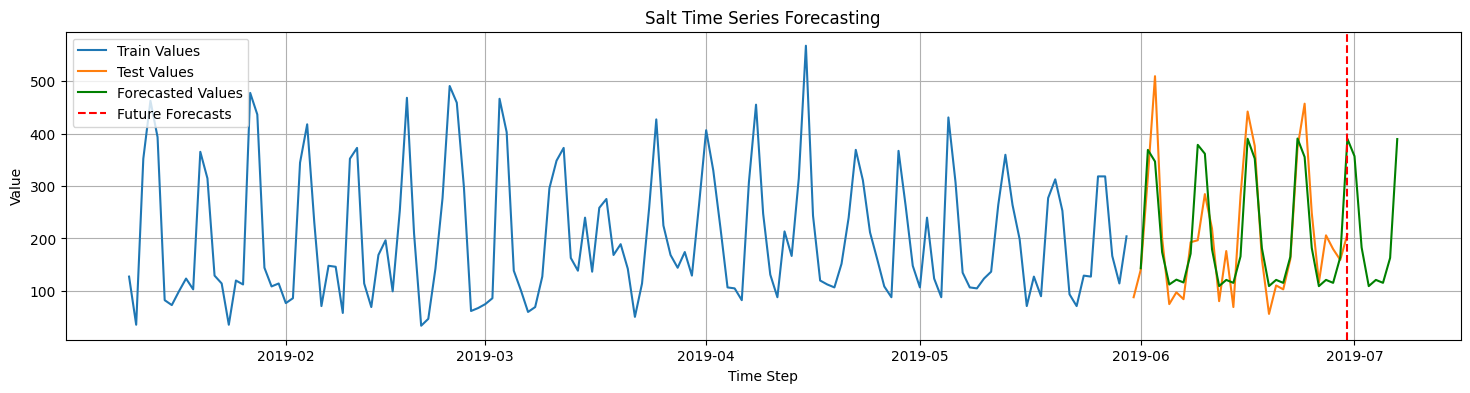

( 1  ,  Sugar )


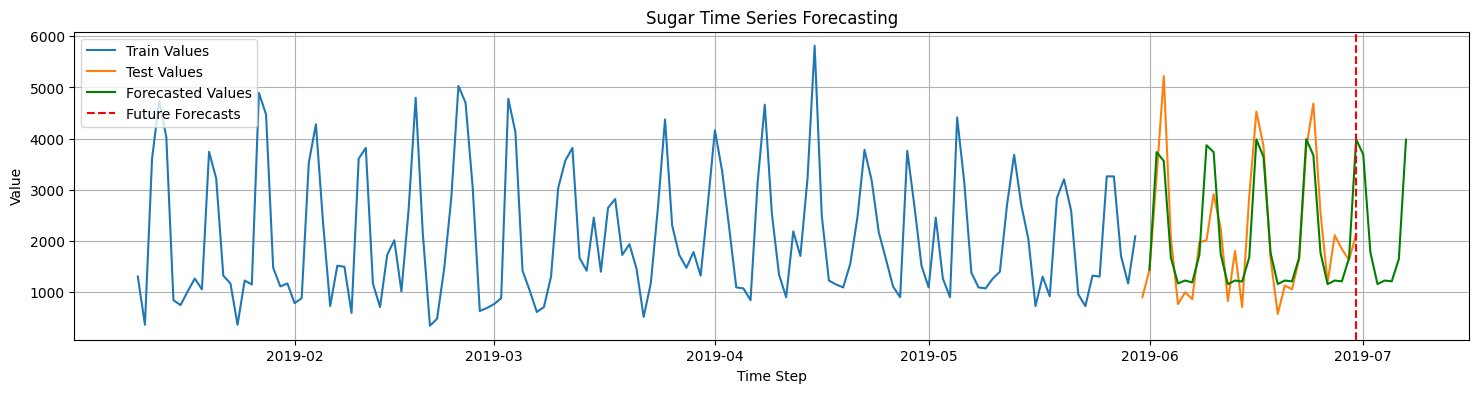

( 2  ,  Clove )


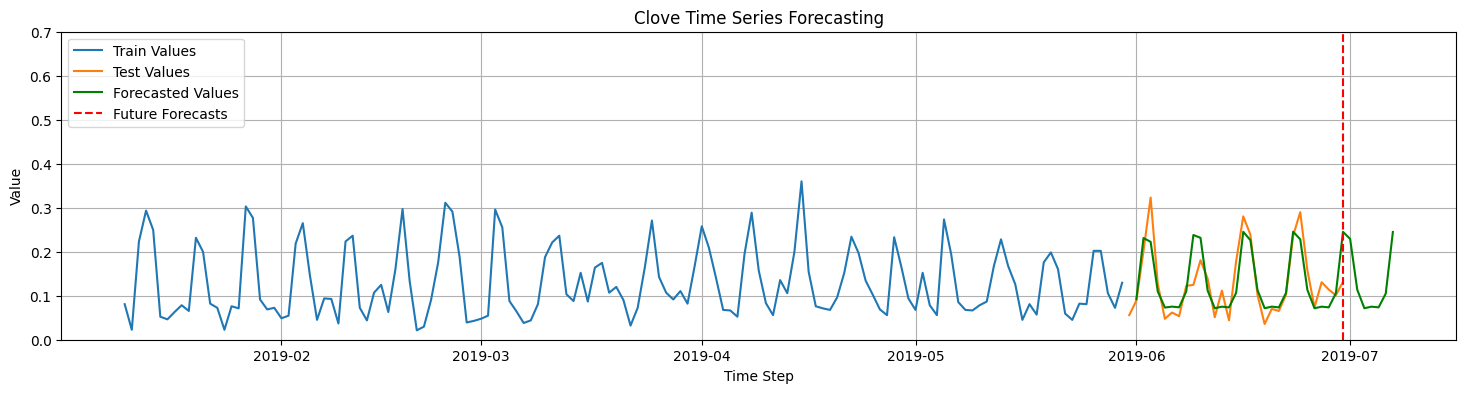

( 3  ,  Paprika )


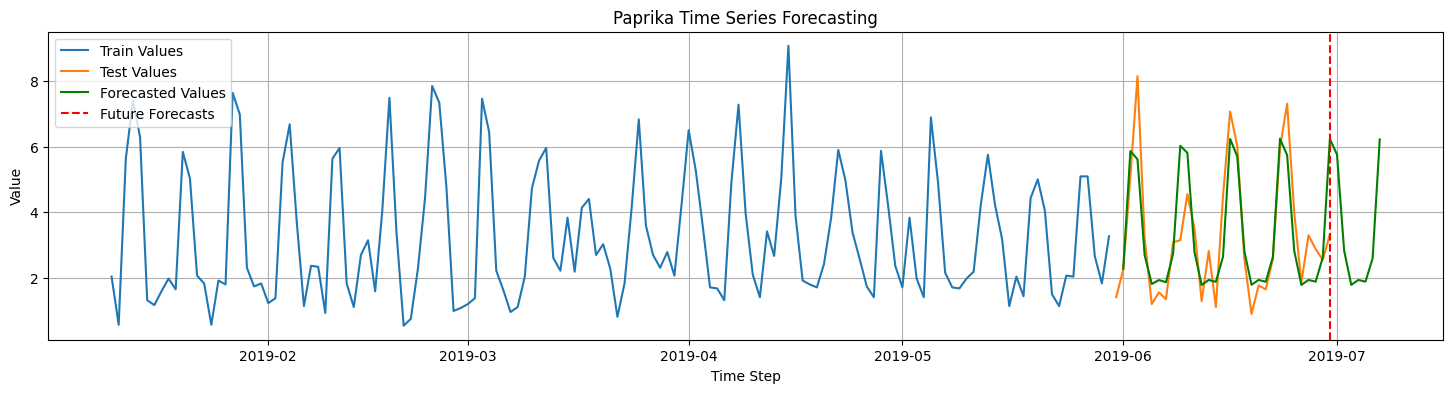

In [13]:
def plot_ingredient_forecasts(ingr, original_time_steps, real_quantities, forecast_time_steps, forecast_values):

    plt.figure(figsize=(18, 4))

    if ingr == "Clove":
        plt.ylim(0, 0.7)

    # Plot the original/train quantities until the predicted date
    plt.plot(original_time_steps[:split_index], real_quantities[:split_index], label = "Train Values") 

    # The historical data used as input for forecasting - all test data
    plt.plot(original_time_steps[split_index:], real_quantities[split_index:], label="Test Values") 

    # plotting the forecasted values
    plt.plot(forecast_time_steps, forecast_values, label='Forecasted Values', color='green')

    limit_time_step = pd.to_datetime("2019-06-30")

    # Find the index of June 30th in original_time_steps
    if limit_time_step in original_time_steps:
        june_30_time_step_idx = original_time_steps.get_loc(limit_time_step)
        plt.axvline(x=original_time_steps[june_30_time_step_idx], color='red', linestyle='--', label='Future Forecasts')

    plt.xlabel('Time Step')
    plt.ylabel('Value')
    plt.legend()
    plt.title(f'{ingr} Time Series Forecasting')
    plt.grid(True)
    plt.show()

future_data = []
for idx, ingredient in enumerate(target_columns):
    print("(", idx," , ", ingredient,")")
    
    # Ingredient real quantities based on the right time step
    ingredient_real_quantities = daily_consumption_df[ingredient][window:]
    # Real Dates based on the right time step
    original_time_steps = daily_consumption_df.index[window:]

    forecasted_cases = scaler.inverse_transform(np.array(forecasted_values))
    ingr_forecast = forecasted_cases[:, idx].reshape(-1, 1)

    # Append forecast values to the list
    future_data.append({
        'ingredient': ingredient,
        'Date': total_forecast_dates[-num_future_steps:], # future dates
        'Forecast Quantity': ingr_forecast[-num_future_steps:].flatten() # future quantities
    })
    
    # Optionally plot the forecasts
    plot_ingredient_forecasts(
        ingredient, 
        original_time_steps, 
        ingredient_real_quantities,  
        total_forecast_dates, 
        ingr_forecast
    )

In [14]:
# Convert list of dictionaries to a DataFrame
df = pd.DataFrame(future_data)

# Convert the DataFrame into a format suitable for pivoting
df = df.explode(['Date', 'Forecast Quantity'])

# Pivot the DataFrame to have dates as index and ingredients as columns
forecast_quantities = df.pivot(index='Date', columns='ingredient', values='Forecast Quantity')
forecast_quantities.columns.name = None

# Print or inspect the result
display(forecast_quantities)

,Clove,Paprika,Salt,Sugar
Date,,,,
2019-07-01,0.229109,5.756786,356.850006,3691.595459
2019-07-02,0.113763,2.831023,182.819229,1780.99939
2019-07-03,0.071562,1.784394,109.189461,1158.737305
2019-07-04,0.075144,1.933197,121.030289,1227.911133
2019-07-05,0.073547,1.881544,115.490883,1213.084839
2019-07-06,0.104884,2.593908,162.939529,1650.603027
2019-07-07,0.244878,6.217712,389.510315,3980.574951


In [15]:
# Print JSON list
import json

# {"ingredientId": "string", "date": "2024-07-25", "quantity": 25, "measureUnit": "kg" }

# Define the ingredient IDs and measure units
ingredient_ids = {
    'Salt': '5ba6c6c1-d2b2-4e11-b5ab-92ecd03ba6ea',
    'Sugar': '5ca0c5cd-923a-410a-85fb-97c1716c97d3',
    'Milk': 'c388bb8c-08c1-4aee-9322-ea9e9fd2df2d',
    'Onion': 'b405114e-8665-45ea-bd75-b6380167003c',
    'Garlic clove': '9b77593e-792d-4e99-9040-d0718499b77b'
}

# Ensure columns are in float64 for compatibility
forecast_quantities = forecast_quantities.astype(float)
display(forecast_quantities)

# Update the year in the index
forecast_quantities.index = forecast_quantities.index.map(lambda x: x.replace(year=2024))

# Convert DataFrame to list of JSON objects
json_list = []
for date, row in forecast_quantities.iterrows():
    for ingredient, quantity in row.items():
        measure_unit = 'g'  # init to grams
        # print("ingredient: ", ingredient)
        # print("quantity: ", quantity)
        final_qty = quantity    # grams
        if final_qty >= 1000:
            final_qty = round(quantity / 1000, 1)
            measure_unit = 'kg'
        else:
            final_qty = round(quantity, 0)
        #print("final_qty: ", final_qty)
        json_obj = {
            "ingredientId": ingredient_ids.get(ingredient, "unknown_id"),
            "date": date.strftime("%Y-%m-%d"),
            "quantity": final_qty,
            "measureUnit": measure_unit
        }
        json_list.append(json_obj)

# Print JSON list
print(json.dumps(json_list, indent=2))


,Clove,Paprika,Salt,Sugar
Date,,,,
2019-07-01,0.229109,5.756786,356.850006,3691.595459
2019-07-02,0.113763,2.831023,182.819229,1780.999390
2019-07-03,0.071562,1.784394,109.189461,1158.737305
2019-07-04,0.075144,1.933197,121.030289,1227.911133
2019-07-05,0.073547,1.881544,115.490883,1213.084839
2019-07-06,0.104884,2.593908,162.939529,1650.603027
2019-07-07,0.244878,6.217712,389.510315,3980.574951


[
  {
    "ingredientId": "unknown_id",
    "date": "2024-07-01",
    "quantity": 0.0,
    "measureUnit": "g"
  },
  {
    "ingredientId": "unknown_id",
    "date": "2024-07-01",
    "quantity": 6.0,
    "measureUnit": "g"
  },
  {
    "ingredientId": "5ba6c6c1-d2b2-4e11-b5ab-92ecd03ba6ea",
    "date": "2024-07-01",
    "quantity": 357.0,
    "measureUnit": "g"
  },
  {
    "ingredientId": "5ca0c5cd-923a-410a-85fb-97c1716c97d3",
    "date": "2024-07-01",
    "quantity": 3.7,
    "measureUnit": "kg"
  },
  {
    "ingredientId": "unknown_id",
    "date": "2024-07-02",
    "quantity": 0.0,
    "measureUnit": "g"
  },
  {
    "ingredientId": "unknown_id",
    "date": "2024-07-02",
    "quantity": 3.0,
    "measureUnit": "g"
  },
  {
    "ingredientId": "5ba6c6c1-d2b2-4e11-b5ab-92ecd03ba6ea",
    "date": "2024-07-02",
    "quantity": 183.0,
    "measureUnit": "g"
  },
  {
    "ingredientId": "5ca0c5cd-923a-410a-85fb-97c1716c97d3",
    "date": "2024-07-02",
    "quantity": 1.8,
    "measureU

In [16]:
# Write JSON list to a file
with open('forecast_data.json', 'w') as json_file:
    json.dump(json_list, json_file, indent=2)